# A mathematical approach of the evolutionary trajectories of a genome

## Two genes simulation with a simple Yule model

We consider the joint evolution of two gene families, denoted $x_1$ and $x_2$, evolving within a single species tree. The species tree is generated under a simple Yule model (pure birth process, no extinction) and is kept small to allow exhaustive inspection of the resulting gene trees.

The two gene families are strictly coupled at the level of speciation. Every bifurcation in the species tree simultaneously triggers a speciation in both $x_1$ and $x_2$, so that each daughter species inherits one copy of each gene. As a result, in the absence of duplication, both gene trees are topologically identical to the species tree.

Divergence between the two families arises exclusively through duplication events, which are modelled as a joint probabilistic decision taken along each branch of the species tree. Three outcomes are possible:

- Only $x_1$ duplicates — with probability *p_dup_x1*.

- Only $x_2$ duplicates — with probability *p_dup_x2*.

- Both $x_1$ and $x_2$ duplicate simultaneously — with a smaller probability *p_dup_both*.

The remaining probability mass corresponds to no duplication on that branch. Whenever a duplication occurs, the affected lineage is split into two descendants that remain within the same species node, in contrast to speciation, where the descendants are distributed across the daughter species.

This model provides a minimal but expressive framework for studying coupled gene family evolution: it isolates the effect of duplications as the sole source of topological disagreement between the two gene trees, while enforcing a shared speciation backbone. It also introduces an explicit form of correlated duplication, allowing the two families to co-expand at the same evolutionary time — a scenario commonly observed in real genomes, where tandem or whole-genome duplications affect multiple loci simultaneously.

Species tree:
((((6:0.03126354249339596,7:0.03126354249339596)4:0.19577641378021615,(8:0.005747117982960183,9:0.005747117982960183)5:0.22129283829065194)3:0.2173363662928428,2:0.44437632256645493)1:0.555623677433545)0:0.0;


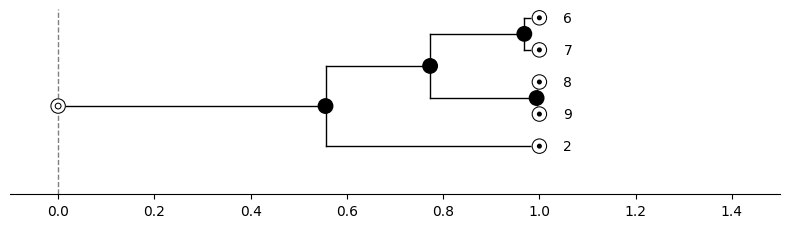

In [61]:
import random
import asymmetree.treeevolve as te
import asymmetree.visualization.tree_vis as tv
from asymmetree.utils.phylogenetic_trees import to_newick
from tralda.datastructures import Tree, TreeNode

# 1. Species tree (Yule model, 5 leaves, no extinction)

n_species = 5
tree_age = 1.0
birth_rate = 1.0

species_tree = te.species_tree_n_age(n_species, tree_age, birth_rate=birth_rate)
print("Species tree:")
print(to_newick(species_tree))
tv.visualize(species_tree, save_as="species_tree.pdf")

This tree is the backbone along which both gene families ($x_1$ and $x_2$) will evolve. The speciation events in this tree will be mirrored by both gene families. Every node in both gene trees must be created with the same three attributes.

Then, we add duplication events. This turns one gene lineage into two, both staying in the same species node. A duplication makes the tree binary (two descendants from one ancestor). The original lineage is replaced by $c_1$ (the surviving original copy), while $c_2$ (the duplicate) is appended to the lineage list.

In [62]:
# 2. Helper functions

def make_gene_node(label, species_node, dist=None):
    """Create a gene tree node associated with a species node."""
    node = TreeNode(label=label)
    node.species = species_node
    if dist is None:
        dist = getattr(species_node, "dist", None)
        if dist is None or dist <= 0:
            dist = random.uniform(0.05, 0.2)
    node.dist = dist
    return node


def apply_duplication(lineages, idx, species_node, family):
    """
    Duplicate a gene lineage.
    Two children are created in the SAME species node (this is what
    distinguishes a duplication from a speciation).
    """
    gene_node, _ = lineages[idx]
    dist = getattr(species_node, "dist", None)
    if dist is None or dist <= 0:
        dist = random.uniform(0.05, 0.2)

    c1 = make_gene_node(f"{family}_{species_node.label}_orig", species_node, dist)
    c2 = make_gene_node(f"{family}_{species_node.label}_dup",  species_node, dist)
    gene_node.add_child(c1)
    gene_node.add_child(c2)
    gene_node.event = "D"

    # Original lineage continues as c1; c2 is a new lineage.
    lineages[idx] = (c1, species_node)
    lineages.append((c2, species_node))


def apply_speciation(lineages, idx, species_children, family):
    """
    Split a gene lineage into copies for each species child.
    Every child of the species node receives its own copy of the gene.
    """
    gene_node, _ = lineages[idx]
    new_entries = []
    for child_sp in species_children:
        dist = getattr(child_sp, "dist", None)
        if dist is None or dist <= 0:
            dist = random.uniform(0.05, 0.2)
        c = make_gene_node(f"{family}_{child_sp.label}", child_sp, dist)
        gene_node.add_child(c)
        new_entries.append((c, child_sp))
    gene_node.event = "S"

    # Replace the original lineage with the first child; append the rest.
    lineages[idx] = new_entries[0]
    for ne in new_entries[1:]:
        lineages.append(ne)

Each family starts with one ancestral gene at the species root and maintains its own list of active lineages. One single random number is drawn per species node. Depending on which interval it falls into, we get one of four outcomes:

- If $[0, p_{x_1})$, then only $x_1$ duplicates.
- If $[p_{x_1}, p_{x_1}+p_{x_2})$, then only $x_2$ duplicates.
- If $[p_{x_1}+p_{x_2}, p_{x_1}+p_{x_2}+p_{x_1, x_2})$, then	both duplicate.
- Otherwise, no duplications with a probability of	$1 - (\textit{sum of the previous ones})$

 The newly-created duplicates also participate in the speciation that follows, giving each species child a copy of every copy.


--- Simulating coupled families x1 and x2 ---

  [speciation]  x1 and x2 speciated at species 0
  [duplication] x1 duplicated at species 1
  [speciation]  x1 and x2 speciated at species 1
  [speciation]  x1 and x2 speciated at species 3
  [speciation]  x1 and x2 speciated at species 4
  [speciation]  x1 and x2 speciated at species 5
  [duplication] x1 duplicated at species 8

Gene tree x1:
(((((x1_6:0.03126354249339596,x1_7:0.03126354249339596)x1_4:0.19577641378021615,((x1_8_orig:0.005747117982960183,x1_8_dup:0.005747117982960183)x1_8:0.005747117982960183,x1_9:0.005747117982960183)x1_5:0.22129283829065194)x1_3:0.2173363662928428,x1_2:0.44437632256645493)x1_1_orig:0.555623677433545,(((x1_6:0.03126354249339596,x1_7:0.03126354249339596)x1_4:0.19577641378021615,((x1_8_orig:0.005747117982960183,x1_8_dup:0.005747117982960183)x1_8:0.005747117982960183,x1_9:0.005747117982960183)x1_5:0.22129283829065194)x1_3:0.2173363662928428,x1_2:0.44437632256645493)x1_1_dup:0.555623677433545)x1_1:0.55562367

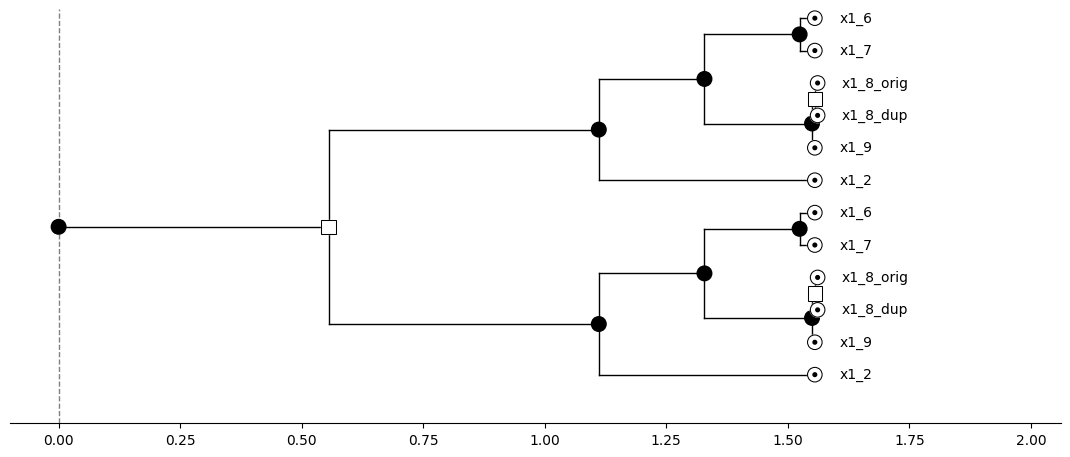

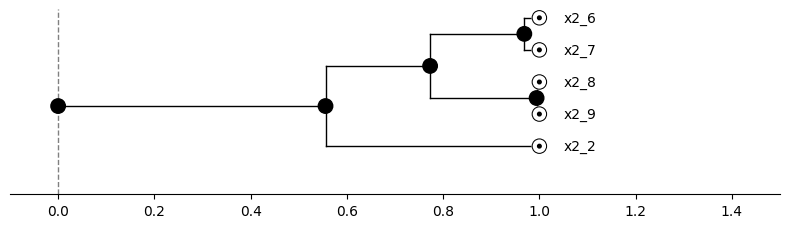

In [63]:
# 3. Coupled simulation of x1 and x2

def simulate_coupled_families(species_tree,
                              p_dup_x1=0.10,
                              p_dup_x2=0.10,
                              p_dup_both=0.03,
                              verbose=True):
    """
    Simulate two coupled gene families (x1 and x2).

    Rules:
      * Every speciation in the species tree ALWAYS triggers speciation
        in BOTH genes.
      * Along each branch, a joint duplication roll happens:
          - p_dup_x1   : only x1 duplicates
          - p_dup_x2   : only x2 duplicates
          - p_dup_both : both duplicate simultaneously
          - remaining  : no duplication at all
    """
    # Initialize both families at the species root
    root_x1 = TreeNode(label="x1_root"); root_x1.dist = 0.0
    root_x1.species = species_tree.root
    tree_x1 = Tree(root_x1)

    root_x2 = TreeNode(label="x2_root"); root_x2.dist = 0.0
    root_x2.species = species_tree.root
    tree_x2 = Tree(root_x2)

    lineages_x1 = [(root_x1, species_tree.root)]
    lineages_x2 = [(root_x2, species_tree.root)]

    # Preorder traversal of the species tree
    
    for M in species_tree.preorder():

        # 1) Joint duplication decision at species node M
        roll = random.random()
        dup_x1 = False
        dup_x2 = False
        if roll < p_dup_x1:
            dup_x1 = True
        elif roll < p_dup_x1 + p_dup_x2:
            dup_x2 = True
        elif roll < p_dup_x1 + p_dup_x2 + p_dup_both:
            dup_x1 = True
            dup_x2 = True

        if dup_x1:
            idxs = [i for i, (_, sp) in enumerate(lineages_x1) if sp == M]
            for i in reversed(idxs):
                apply_duplication(lineages_x1, i, M, "x1")
            if verbose:
                print(f"  [duplication] x1 duplicated at species {M.label}")

        if dup_x2:
            idxs = [i for i, (_, sp) in enumerate(lineages_x2) if sp == M]
            for i in reversed(idxs):
                apply_duplication(lineages_x2, i, M, "x2")
            if verbose:
                print(f"  [duplication] x2 duplicated at species {M.label}")

        # 2) Mandatory speciation (only if M is an internal node)
        
        if M.children:
            children = list(M.children)   # usually 2 children
            for family, lineages in [("x1", lineages_x1), ("x2", lineages_x2)]:
                idxs = [i for i, (_, sp) in enumerate(lineages) if sp == M]
                for i in reversed(idxs):
                    apply_speciation(lineages, i, children, family)
            if verbose:
                print(f"  [speciation]  x1 and x2 speciated at species {M.label}")

    # Finalize: mark leaves and ensure all dists are set
    for tree in (tree_x1, tree_x2):
        for leaf in tree.leaves():
            leaf.event = "S"
        for v in tree.preorder():
            if v.parent is not None:
                if not hasattr(v, "dist") or v.dist is None:
                    v.dist = random.uniform(0.05, 0.2)

    return tree_x1, tree_x2

# 4. Run the simulation

print("\n--- Simulating coupled families x1 and x2 ---\n")
tree_x1, tree_x2 = simulate_coupled_families(species_tree)

print("\nGene tree x1:")
print(to_newick(tree_x1, reconc=True))
tv.visualize(tree_x1, save_as="gene_x1.pdf")

print("\nGene tree x2:")
print(to_newick(tree_x2, reconc=True))
tv.visualize(tree_x2, save_as="gene_x2.pdf")

- The number of speciation events "$S$" in $x_1$ and $x_2$ should be identical (both follow the species tree's speciation structure).

- The number of duplication events "$D$" may differ, depending on which duplication rolls fired.

In [64]:
# 5. Event summary

def count_events(tree):
    counts = {"S": 0, "D": 0}
    for node in tree.preorder():
        if hasattr(node, "event") and node.event in counts:
            counts[node.event] += 1
    return counts

print("\nEvent summary:")
print("x1:", count_events(tree_x1))
print("x2:", count_events(tree_x2))


Event summary:
x1: {'S': 21, 'D': 3}
x2: {'S': 10, 'D': 0}


## Simulation for $n$ genes with a simple Yule model approach

Now, let's consider the joint evolution of an ordered set of distinct genes, $x_1, x_2, x_3, ... , x_n$, embedded in a genome whose linear order is explicitly tracked along a species tree. The species tree is generated under a simple Yule model and kept small to allow exhaustive inspection of the resulting gene trees.

Divergence between gene families arises exclusively through single-gene duplications, modelled as a probabilistic event that occurs along each branch of the species tree. When a gene duplicates, its copy is inserted into the ordered genome according to one of two mechanisms:

- Tandem duplication — with probability $p_\textit{tandem}$, the duplicate is placed immediately adjacent to the original gene, either before or after it in the sequence. For example: $x_1, x_2, x^d_2, x_3, ... , x_n$ or $x_1, x^d_2, x_2, x_3, ... , x_n$.

- Dispersed duplication — with probability $1−p_\textit{tandem}$, the duplicate is inserted at a random position in the genome, potentially far from the original.

We'll only one gene duplicates per event, in line with the requirement to avoid simultaneous multi-gene duplication scenarios. By tracking the genome as an ordered list, the model captures two biologically meaningful layers at once: the gene tree topology (who descends from whom) and the genomic architecture (where each gene copy physically resides).

Species tree:
(((4:0.03744614007837552,5:0.03744614007837552)2:0.3901804897818144,3:0.42762662986018996)1:0.57237337013981)0:0.0;


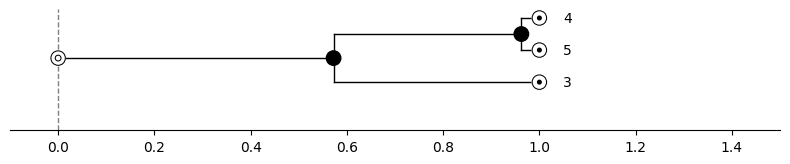

In [65]:
import random
import asymmetree.treeevolve as te
import asymmetree.visualization.tree_vis as tv
from asymmetree.utils.phylogenetic_trees import to_newick
from tralda.datastructures import Tree, TreeNode


# 1. Species tree (Yule model, 5 leaves, no extinction)

n_species = 3
tree_age = 1.0
birth_rate = 1.0

species_tree = te.species_tree_n_age(n_species, tree_age, birth_rate=birth_rate)
print("Species tree:")
print(to_newick(species_tree))
tv.visualize(species_tree, save_as="species_tree.pdf")

We create a species tree with just 3 leaves under the Yule model (pure birth, no extinction).

- *n_genes*: size of the ancestral genome (how many distinct gene families start at the root).

- *p_dup*: per-branch probability that a duplication happens. Applied before the speciation step at each species node.

- *p_tandem*: conditional on a duplication occurring, the probability that it is a tandem event (inserted adjacent to the original). With $1 − p_\textit{tandem}$, the duplication is dispersed (inserted at a random position).

The genome is not just a set of genes; it is an ordered list. This ordering is essential for modeling tandem duplications (which insert adjacent to the original).

In [66]:
# 2. Parameters

n_genes = 4          # number of initial gene families: x1, x2, ..., xn
p_dup = 0.4          # probability of a duplication on a given branch
p_tandem = 0.6       # conditional on duplication: prob. of tandem (adjacent)


# 3. Helper: create a gene node with all required attributes

def make_gene_node(label, species_node, event=None):
    node = TreeNode(label=str(label))          # <-- FIX: force string
    node.species = species_node
    dist = getattr(species_node, "dist", None)
    if dist is None or dist <= 0:
        dist = random.uniform(0.05, 0.2)
    node.dist = dist
    if event is not None:
        node.event = event
    return node

# 4. Initialize the ancestral genome as an ordered list of genes

initial_genome = []
gene_roots = {}
for k in range(1, n_genes + 1):
    label = f"x{k}"
    root = TreeNode(label=str(label))          # <-- FIX: force string
    root.species = species_tree.root
    root.dist = 0.0
    gene_roots[label] = root
    initial_genome.append((root, species_tree.root))

print(f"\nAncestral genome: [{' , '.join(gene_roots.keys())}]")


Ancestral genome: [x1 , x2 , x3 , x4]


We apply a coupled simulation loop. It walks the species tree in preorder (root → leaves) and, at each species node $M$, induces duplications and speciations. The genome is shown as a dictionary that will store the ordered genome for every species node. Duplication is applied before speciation. This means that if a gene duplicates at node $M$, both the original and the duplicate get carried into every daughter species by the speciation step. So a duplication at an internal node produces a duplication inherited by all descendant species.

- The tandem case inserts *c_dup* either immediately before ($i - 1$) or immediately after ($i + 1$) the original.

- The dispersed case picks a random insertion point $pos \in [0, len(current)]$, allowing the duplicate to land anywhere — including the beginning or end of the chromosome.

In [67]:
# 5. Simulate along the species tree (preorder traversal)

genomes = {species_tree.root: initial_genome}

for M in species_tree.preorder():

    # ---------- Retrieve the genome at node M ----------
    if M == species_tree.root:
        current = list(initial_genome)
    else:
        current = list(genomes[M])

    # ---------- Duplication phase (single-gene duplication) ----------
    if current and random.random() < p_dup:
        i = random.randrange(len(current))
        gene_node, _ = current[i]

        c_orig = make_gene_node(f"{gene_node.label}_orig", M)
        c_dup = make_gene_node(f"{gene_node.label}_dup", M)
        gene_node.add_child(c_orig)
        gene_node.add_child(c_dup)
        gene_node.event = "D"

        # The original copy keeps its position
        current[i] = (c_orig, M)

        # Decide where the duplicate is inserted
        if random.random() < p_tandem:
            if random.random() < 0.5:
                current.insert(i, (c_dup, M))
                mode = "tandem-before"
            else:
                current.insert(i + 1, (c_dup, M))
                mode = "tandem-after"
        else:
            pos = random.randrange(len(current) + 1)
            current.insert(pos, (c_dup, M))
            mode = f"dispersed (pos {pos})"

        print(f"  [D] {gene_node.label} duplicated at species {M.label} "
              f"-> {mode}")

    # Speciation phase (mandatory for every gene)
    if M.children:
        for daughter in M.children:
            new_genome = []
            for gene_node, _ in current:
                c = make_gene_node(daughter.label, daughter)
                gene_node.add_child(c)
                gene_node.event = "S"
                new_genome.append((c, daughter))
            genomes[daughter] = new_genome
    else:
        genomes[M] = current

  [D] x3 duplicated at species 0 -> tandem-before
  [D] 4 duplicated at species 4 -> tandem-after
  [D] 5 duplicated at species 5 -> tandem-before


All families share the same number of $S$ events up to the point where duplications add extra $S$ events (since every duplicated copy also undergoes subsequent speciations). $D$ counts differ across families: a family that duplicates more often has more internal duplication nodes.


--- Ordered genomes at extant species ---
  4: [4 , 4 , 4_orig , 4_dup , 4 , 4]
  5: [5 , 5 , 5 , 5 , 5_dup , 5_orig]
  3: [3 , 3 , 3 , 3 , 3]

Gene tree for family x1:
(((4:0.03744614007837552,5:0.03744614007837552)2:0.3901804897818144,3:0.42762662986018996)1:0.57237337013981)x1:0.0;

Gene tree for family x2:
(((4:0.03744614007837552,5:0.03744614007837552)2:0.3901804897818144,3:0.42762662986018996)1:0.57237337013981)x2:0.0;

Gene tree for family x3:
((((4:0.03744614007837552,5:0.03744614007837552)2:0.3901804897818144,3:0.42762662986018996)1:0.57237337013981)x3_orig:0.13116322549117365,((((4_orig:0.03744614007837552,4_dup:0.03744614007837552)4:0.03744614007837552,5:0.03744614007837552)2:0.3901804897818144,3:0.42762662986018996)1:0.57237337013981)x3_dup:0.1589743446655835)x3:0.0;

Gene tree for family x4:
(((4:0.03744614007837552,(5_orig:0.03744614007837552,5_dup:0.03744614007837552)5:0.03744614007837552)2:0.3901804897818144,3:0.42762662986018996)1:0.57237337013981)x4:0.0;

--- Event s

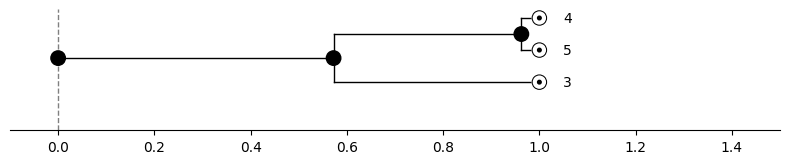

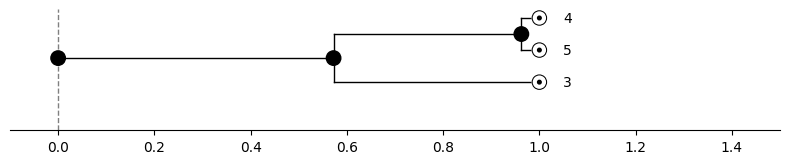

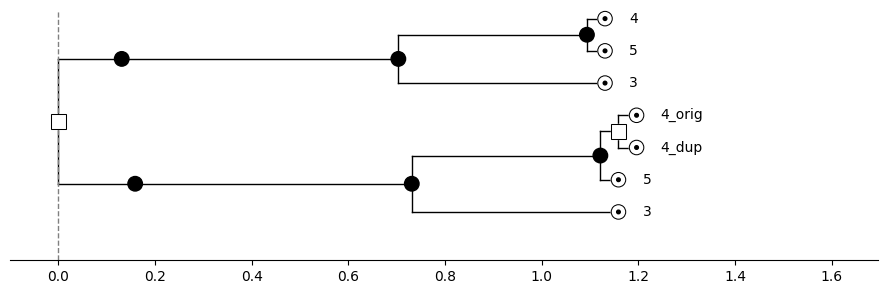

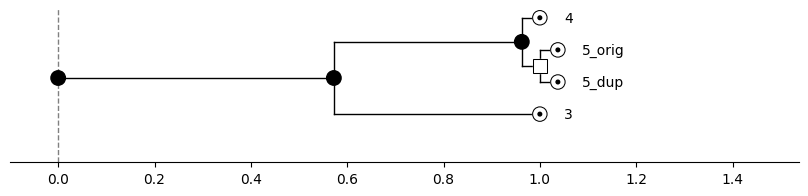

In [68]:
# 6. Finalize trees: ensure dists, mark extant leaves

gene_trees = {}
for label, root in gene_roots.items():
    tree = Tree(root)
    for v in tree.preorder():
        if v.parent is not None and (not hasattr(v, "dist") or v.dist is None):
            v.dist = random.uniform(0.05, 0.2)
        if not v.children:
            v.event = "S"
    gene_trees[label] = tree


# 7. Show the ordered genome at each extant species (leaf)

print("\n--- Ordered genomes at extant species ---")
for leaf in species_tree.leaves():
    genome = genomes[leaf]
    seq_str = " , ".join(str(node.label) for node, _ in genome)
    print(f"  {str(leaf.label)}: [{seq_str}]")


# 8. Print and visualize each gene tree

for label, tree in gene_trees.items():
    print(f"\nGene tree for family {label}:")
    print(to_newick(tree, reconc=True))
    tv.visualize(tree, save_as=f"gene_{label}.pdf")


# 9. Event summary per gene family

def count_events(tree):
    counts = {"S": 0, "D": 0}
    for v in tree.preorder():
        if hasattr(v, "event") and v.event in counts:
            counts[v.event] += 1
    return counts

print("\n--- Event summary per family ---")
for label, tree in gene_trees.items():
    print(f"  {label}: {count_events(tree)}")

In [69]:

# Summary: original genome vs final genomes

def genome_str(genome):
    return " , ".join(str(node.label) for node, _ in genome)

print("\n" + "=" * 60)
print("GENOME EVOLUTION SUMMARY")
print("=" * 60)
print(f"Original genome:       [{genome_str(initial_genome)}]")
print("-" * 60)
for leaf in species_tree.leaves():
    print(f"Final genome at {str(leaf.label)}: [{genome_str(genomes[leaf])}]")
print("=" * 60)


GENOME EVOLUTION SUMMARY
Original genome:       [x1 , x2 , x3 , x4]
------------------------------------------------------------
Final genome at 4: [4 , 4 , 4_orig , 4_dup , 4 , 4]
Final genome at 5: [5 , 5 , 5 , 5 , 5_dup , 5_orig]
Final genome at 3: [3 , 3 , 3 , 3 , 3]
